In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from fredapi import Fred
import itertools
import ipywidgets as widgets
from ipywidgets import interact
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#downloaded all the dependencies

In [2]:
gold = yf.Ticker("GLD")
euro = yf.Ticker("^STOXX50E")
fx = yf.Ticker("JPY=X")
ief = yf.Ticker("IEF")
gspc = yf.Ticker("^GSPC")
oil = yf.Ticker("CL=F")
nikki = yf.Ticker("^N225")
copper = yf.Ticker("CPER")

In [3]:
final_data = yf.download(tickers=["^GSPC", "CL=F", "^N225", "CPER", "GLD", "IEF", "JPY=X", "^STOXX50E"], start="2024-02-09", end="2026-02-09")
final_data.ffill(inplace=True)
final_data.bfill(inplace=True)
new_closed_data = final_data['Close']
new_normalized = new_closed_data/new_closed_data.iloc[0]

[*********************100%***********************]  8 of 8 completed


In [8]:
new_log_returns = np.log(final_data['Close']).diff()
new_log_returns.ffill(inplace = True)
new_log_returns.bfill(inplace = True)

all_roll_corr = new_log_returns.rolling(window=30).corr()
all_roll_corr.dropna(inplace=True)


In [5]:
dates = all_roll_corr.index.get_level_values(0).unique()
@interact(date_index = widgets.IntSlider(min=0, max = len(dates)-1, step=1, value = 0, description = 'Timeline'))

#defining function to get heatmap using interact
def plot_rolling_heatmap(date_index):
    target_date = dates[date_index]
    matrix_frame = all_roll_corr.loc[target_date]
    
    plt.figure(figsize= (20,10))
    sns.heatmap(data=matrix_frame, annot = True,
                fmt = ".2f", cmap = 'coolwarm',
                vmax=1, vmin=-1, center = 0)
    plt.title(f"Rolling function heatmap: {target_date.strftime('%Y-%m-%d')}")
    plt.show()

interactive(children=(IntSlider(value=0, description='Timeline', max=489), Output()), _dom_classes=('widget-in…

In [6]:
#This is the basic idea of the heatmap - we can enhance it by applying PCA and absorption ratio
# Lets do that next, but the basic idea of the heatmap has been completed.

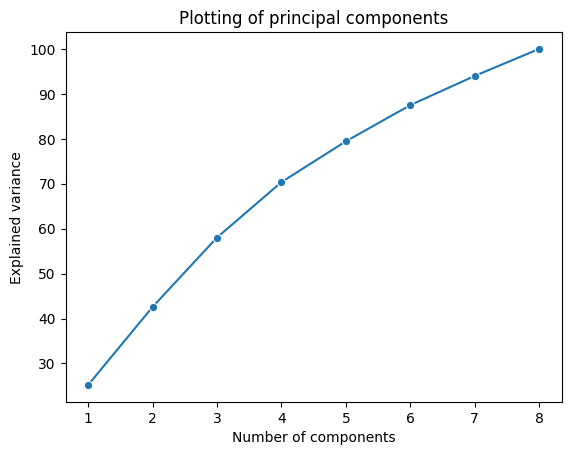

In [42]:
X = new_log_returns.dropna().corr()
#now find the eigen values using the eigen value library function

eigen_values = np.sort(np.linalg.eigvalsh(X))[::-1]
eigen_vectors = np.linalg.eig(X)

#Now find the principal components using the concept of explained variance

explained_variance =eigen_values/eigen_values.sum() *100
cumulative_variance = np.cumsum(explained_variance)

#Now we plot the principal components 
sns.lineplot(x=[1,2,3,4,5,6,7,8], y=cumulative_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("Plotting of principal components")
plt.show()

In [54]:
#Now we understand a lesser-known topic called absorption ratio
# It is defined as a fraction of the total variance of set of assets explained by its eigen vectors
absorption_ratio = []
n_components = 2
for date in dates:
    matrix = all_roll_corr.loc[date].values
    eigenvalues = np.linalg.eigvalsh(matrix)
    
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    ar = np.sum(eigenvalues[:n_components])/(np.sum(eigenvalues))
    absorption_ratio.append(ar)

absorption_ratio_series = pd.Series(absorption_ratio, index = dates)
absorption_ratio_series

Date
2024-03-21    0.485025
2024-03-22    0.486385
2024-03-25    0.483582
2024-03-26    0.475812
2024-03-27    0.479328
                ...   
2026-02-02    0.504210
2026-02-03    0.513954
2026-02-04    0.514554
2026-02-05    0.494180
2026-02-06    0.499300
Length: 490, dtype: float64

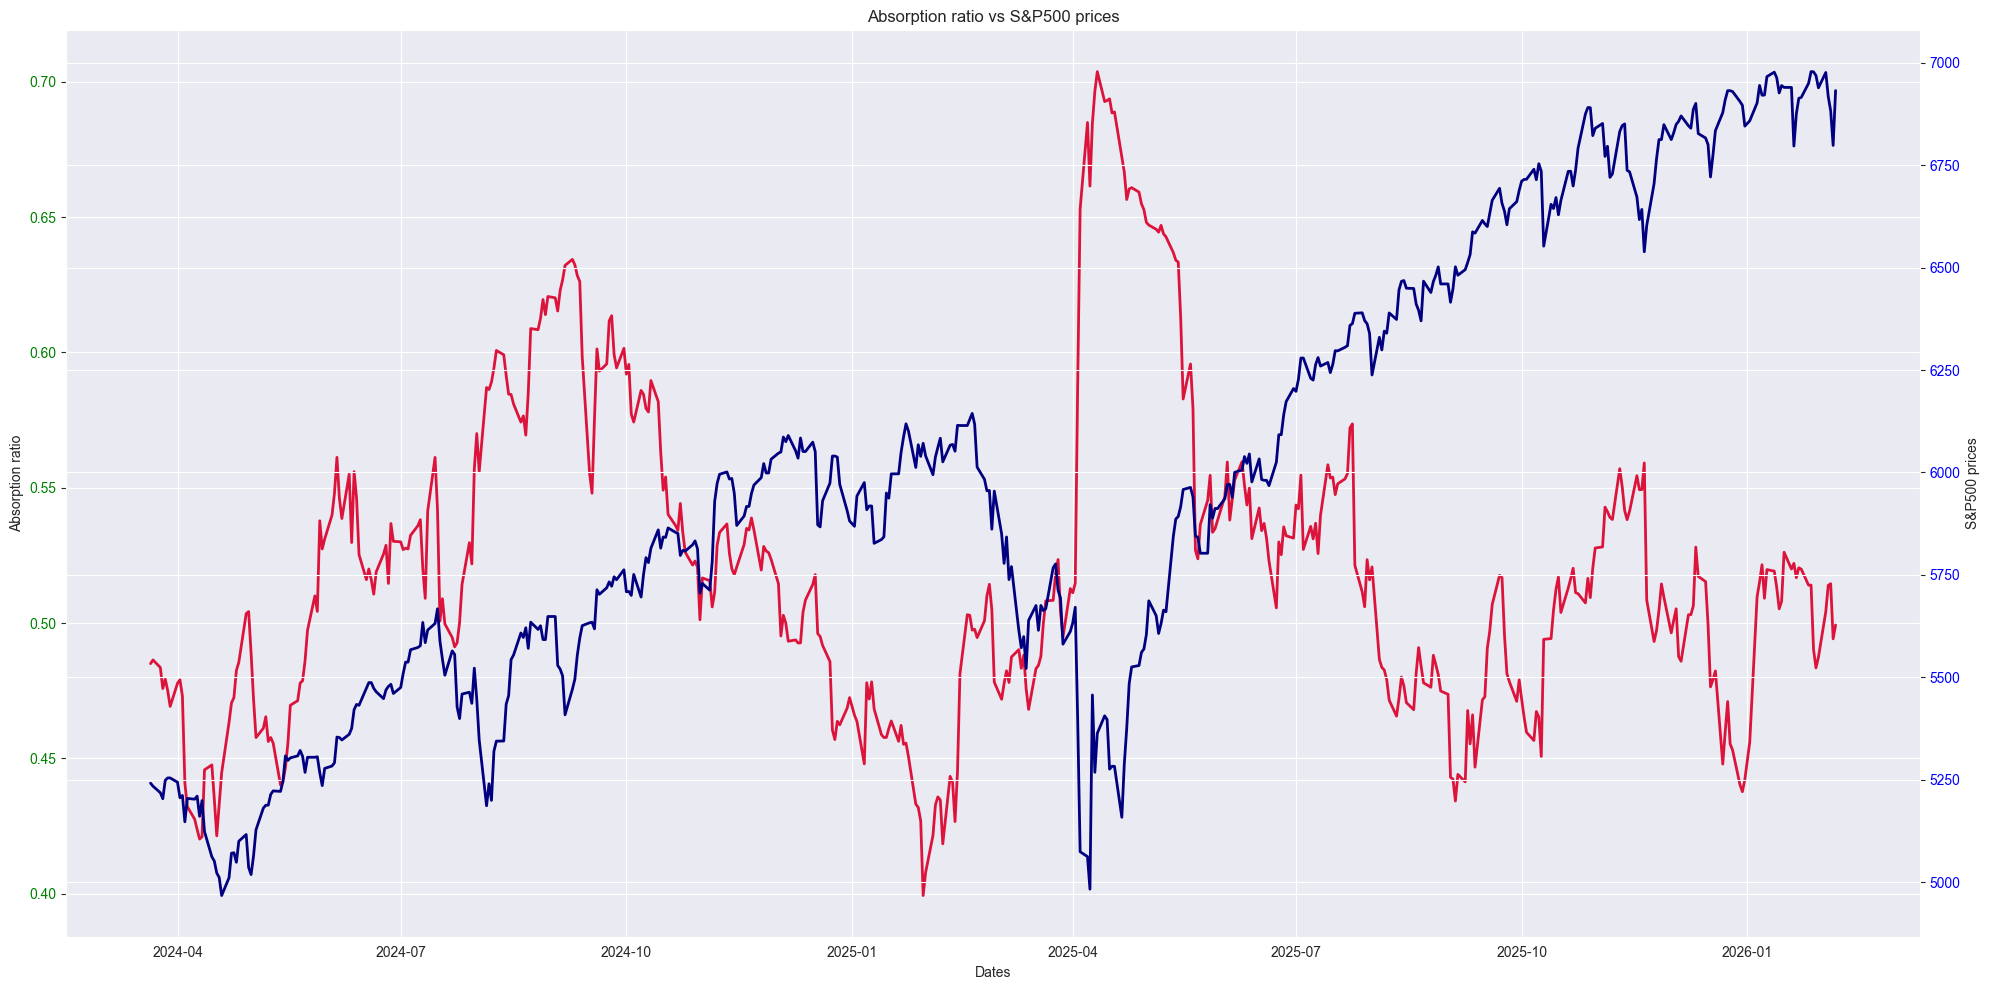

In [ ]:
# Computing the absorption ratio trends with respect to the s&p500 line gives us a better clarity on market trends
sp500 = final_data['Close']['^GSPC'].loc[absorption_ratio_series.index]
#We will use a dual-graph where leftside shows absorption ratio while right side shows the s&p graph trends

fig, ax1 = plt.subplots(figsize=(20,10))
sns.set_style('darkgrid')

ax1.plot(absorption_ratio_series, color='crimson', linewidth=2, label='Absorption ratio')
ax1.set_xlabel('Dates')
ax1.set_ylabel('Absorption ratio')
ax1.tick_params(axis='y', labelcolor='green')

ax2=ax1.twinx()

ax2.plot(sp500, color='navy', linewidth=2, label='S&P500 market')
ax2.set_ylabel('S&P500 prices')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Absorption ratio vs S&P500 prices")
plt.tight_layout()
plt.show()
#Notice that when the absorption ratio is soaring high, the s&p500 prices are at an all time low and vice-versa

In [64]:
#We add a risk high and risk low factor to the data using quantiles and a few basic if cases
hi, low = absorption_ratio_series.quantile(0.80), absorption_ratio_series.quantile(0.20)
def label(x):
    if x>= hi:
        return "risk-off"
    if x<=low:
        return "risk-on"
    return "neutral"

regimes = absorption_ratio_series.apply(label)
#We can also add a kritsman standardized shift to flag huge jumps
delta = (absorption_ratio_series.rolling(15).mean() - absorption_ratio_series.rolling(252).mean())/absorption_ratio_series.rolling(252).std()

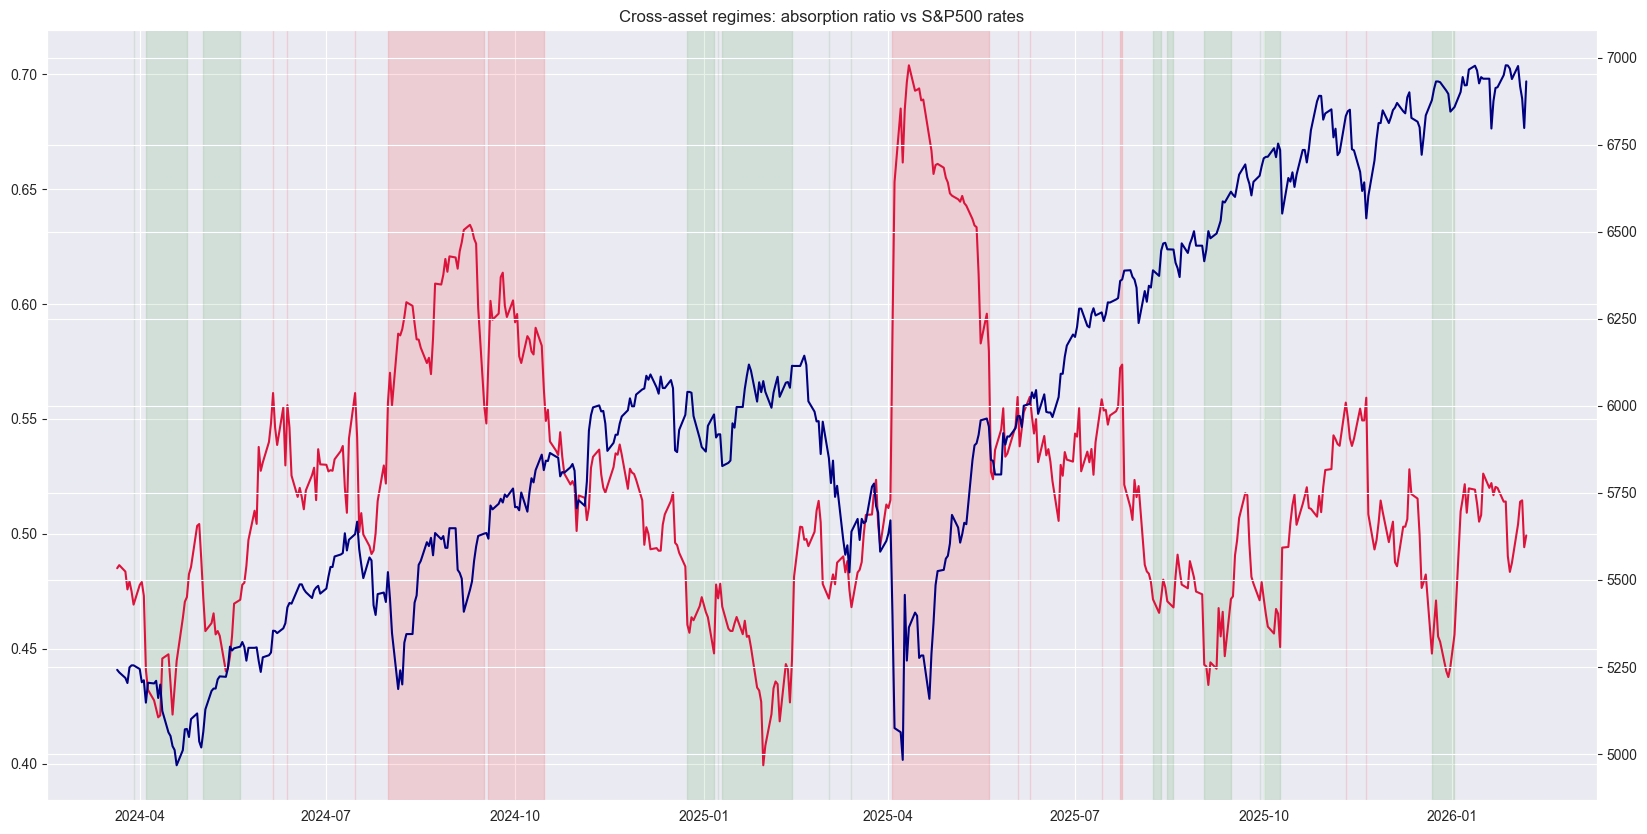

In [68]:
#Just to make the graph more understandable - we add a bit of shade to it
# where the color green shows risk-on while color red shows risk-off
fig, ax1 = plt.subplots(figsize=(20, 10))
ax2 = ax1.twinx()
ax1.plot(absorption_ratio_series.index, absorption_ratio_series, color='crimson', label='Absorption ratio')
ax2.plot(sp500.index, sp500, color='navy', label='S&P 500')

state, idx =regimes.values, regimes.index
start = 0
for i in range(1, len(state)+1):
    if i==len(state) or state[i] != state[start]:
        if state[start] == "risk-off":
            ax1.axvspan(idx[start], idx[i-1], color='red', alpha=0.12)
        elif state[start] == "risk-on":
            ax1.axvspan(idx[start], idx[i-1], color='green', alpha=0.10)
            
        start = i
        ax1.set_title("Cross-asset regimes: absorption ratio vs S&P500 rates")
plt.show()

In [ ]:
dates = all_roll_corr.index.get_level_values(0).unique()
regime_color = {"risk-off":"crimson", "risk-on":"green", "neutral":"gray"}

@interact(date_index = widgets.IntSlider(min=0, max = len(dates)-1, step=1, value = 0, description = 'Timeline'))

#defining function to get heatmap using interact
def plot_rolling_heatmap(date_index):
    target_date = dates[date_index]
    matrix_frame = all_roll_corr.loc[target_date]
    
    ar_values = absorption_ratio_series.loc[target_date]
    regime_value = regimes[target_date]
    plt.figure(figsize= (20,10))
    sns.heatmap(data=matrix_frame, annot = True,
                fmt = ".2f", cmap = 'coolwarm',
                vmax=1, vmin=-1, center = 0)
    plt.title(f"Rolling function heatmap: {target_date.strftime('%Y-%m-%d')}    | "
              f"Absorption ratio: {ar_values:.4f}   "
              f"Regime values: {regime_value.upper()}", color=regime_color.get(regime_value, "black"))
    plt.show()

interactive(children=(IntSlider(value=0, description='Timeline', max=489), Output()), _dom_classes=('widget-in…

In [70]:
# Thats the end of our very first heatmap project